In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
image_path = 'test.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(312, 252, 3)

In [3]:
def translation(tx, ty):
    return np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], dtype=np.float64)


def rotation(angle, c):
    a = np.deg2rad(angle)
    R = np.array([[np.cos(a), np.sin(a), 0], [-np.sin(a), np.cos(a), 0], [0, 0, 1]])
    return translation(*c) @ R @ translation(-c[0], -c[1])


def scaling(s, c):
    S = np.array([[s, 0, 0], [0, s, 0], [0, 0, 1]], dtype=np.float64)
    return translation(*c) @ S @ translation(-c[0], -c[1])

In [4]:
h, w = img.shape[:2]
canvas = (600, 600)
grip = np.array([300, 300])
offset = np.array([80, -60])
angle = 35

place = translation(*(grip + offset - np.array([w / 2, h / 2])))
misplaced = cv2.warpAffine(img, (rotation(angle, grip + offset) @ place)[:2], canvas)

In [5]:
R = rotation(-angle, grip + offset)
T = translation(*(-offset))
M = T @ R

fixed = cv2.warpAffine(misplaced, M[:2], canvas)

print(np.round(M, 3))
print('det of 2x2 part:', round(np.linalg.det(M[:2, :2]), 3))

[[   0.819   -0.574  126.381]
 [   0.574    0.819 -114.556]
 [   0.       0.       1.   ]]
det of 2x2 part: 1.0


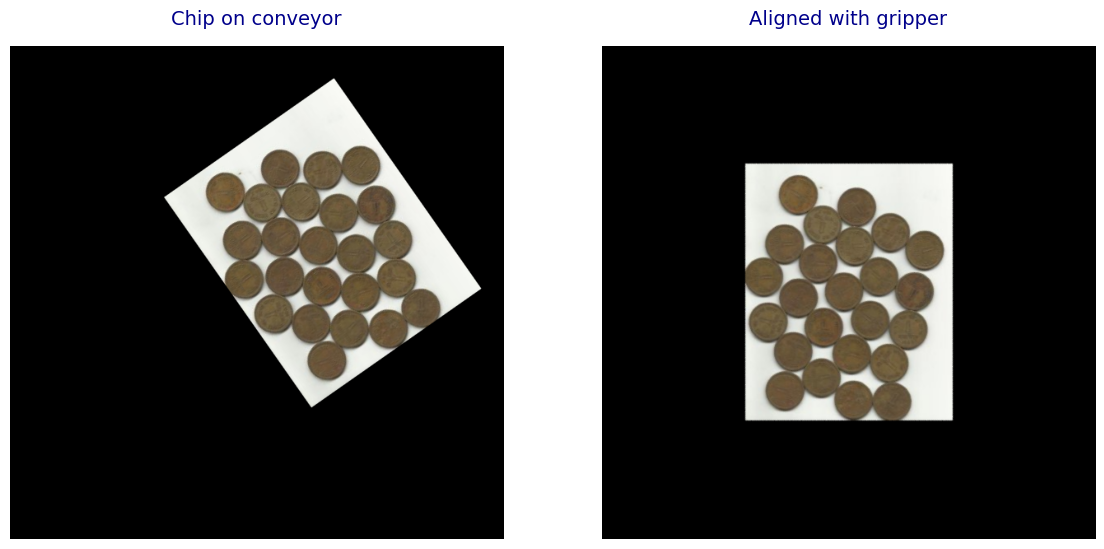

In [6]:
panels = [('Chip on conveyor', misplaced), ('Aligned with gripper', fixed)]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [7]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task5_rigid.png', cv2.cvtColor(fixed, cv2.COLOR_RGB2BGR))

True

M = T @ R. R rotates the chip back by -35 about its own center and T moves that center to the gripper position at (300, 300). Both are in one 3x3 so the image is resampled only once.

Order matters here. Rotating about the chip center first and translating after keeps it simple, doing it the other way round with the same numbers puts the chip somewhere else.

Determinant of the 2x2 part is 1 so there is no scaling or shearing, lengths and angles stay the same. That is what makes it rigid.